# Práctica 3. Sensado y análisis inercial
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.

El objetivo de esta práctica es desarrollar un sistema de clasificación de tiros de baloncesto utilizando datos de IMUs. Para ello, se empleará un modelo de aprendizaje automático que pueda distinguir si un tiro fue exitoso o fallido basándose en las características extraídas de los datos de los sensores.

## Importación de bibliotecas

In [55]:
import os
import re
from tqdm import tqdm
import random

# Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.signal import butter, filtfilt

## Procesamiento

In [56]:
dataset_path = './dataset'

In [57]:
dataset_df = pd.DataFrame(
    columns=[
        "file_name",
        "file_path",
        "student_id",
        "sample_number",
    ]
)

Cargamos los archivos del imu y guardamos sus detalles en un DataFrame de pandas.

In [58]:
rows = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-z]+)_([0-9]+)\.csv", file)
            if match:
                student_id = match.group(1)
                sample_number = match.group(2)
                
                rows.append(
                    {
                        "file_name": file,
                        "file_path": file_path,
                        "student_id": student_id,
                        "sample_number": sample_number,
                    }
                )

dataset_df = pd.concat([dataset_df, pd.DataFrame(rows)], ignore_index=True)

In [59]:
dataset_df.head()

,file_name,file_path,student_id,sample_number
0,Edgar_01.csv,./dataset\Edgar_01.csv,Edgar,01
1,Edgar_02.csv,./dataset\Edgar_02.csv,Edgar,02
2,Edgar_03.csv,./dataset\Edgar_03.csv,Edgar,03
3,Edgar_04.csv,./dataset\Edgar_04.csv,Edgar,04
4,Edgar_05.csv,./dataset\Edgar_05.csv,Edgar,05


Seleccionamos un archivo al azar para inspeccionar sus datos.

In [60]:
data_sensor = pd.read_csv(dataset_df.iloc[0]["file_path"])
data_sensor.head()

,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,5,0.00,0,0.711285,0.445489,-0.438775,-4.186089,-25.954462,37.283886,-11.897106,...,-0.056051,-0.031644,-0.093133,-0.251966,0.225923,-0.162264,0.0,0.0,0.0,0.0
1,5,0.01,1,0.716007,0.412368,-0.476258,1.774544,-33.612278,43.597775,-11.107863,...,-0.057973,-0.034808,-0.096157,-0.264523,0.265432,-0.179785,0.0,0.0,0.0,0.0
2,5,0.02,2,0.638184,0.426291,-0.477852,10.980103,-41.389175,52.426315,-11.107863,...,-0.090770,-0.058823,-0.086476,-0.176743,0.242873,-0.206875,0.0,0.0,0.0,0.0
3,5,0.03,3,0.556013,0.431206,-0.517698,20.320208,-45.200264,62.977596,-10.377083,...,-0.094731,-0.063465,-0.089757,-0.066843,0.226866,-0.229977,0.0,0.0,0.0,0.0
4,5,0.04,4,0.515587,0.421873,-0.555837,30.499054,-47.926231,72.878075,-9.675533,...,-0.099559,-0.068996,-0.092894,-0.025297,0.256047,-0.250635,0.0,0.0,0.0,0.0


Definimos mapeos para los nombres de los sensores y los tiro exitosos.

In [61]:
sensor_id_mapping = {
    5: "Antebrazo",
    4: "Bicep",
    2: "Mano",
}

exitos_mapping = {
    "Mariel": {3, 14, 17},
    "Erick": {1, 3, 13},
    "Juliet": {7, 10},
    "Ian": {5, 6, 7, 10},
    "Zarif": {6},
    "Edgar": {7, 8, 16},
    "Javier": {3, 4, 7, 10},
    "Norman": {2, 3, 5, 9},
}

Cargamos los datos de cada archivo, asignamos etiquetas de éxito o fallo, y combinamos todo en un DataFrame final.

In [62]:
all_results = []
for idx, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    file_path = row["file_path"]
    student_id = row["student_id"]
    sample_number = int(row["sample_number"])

    data_sensor = pd.read_csv(file_path)

    data_sensor["sensor_name"] = data_sensor["SensorId"].map(sensor_id_mapping)
    data_sensor["is_exito"] = int(sample_number in exitos_mapping.get(student_id, set()))
    
    for _, sensor_row in data_sensor.iterrows():
        all_results.append(
            {
                "student_id": student_id,
                "sample_number": sample_number,
                "is_exito": sample_number in exitos_mapping.get(student_id, set()),
                "sensor_name": sensor_row["sensor_name"],
                **sensor_row
            }
        )

df_results = pd.DataFrame(all_results)
df_results.head()

100%|██████████| 112/112 [00:04<00:00, 22.43it/s]


,student_id,sample_number,is_exito,sensor_name,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,Edgar,1,0,Antebrazo,5,0.00,0,0.711285,0.445489,-0.438775,...,-0.056051,-0.031644,-0.093133,-0.251966,0.225923,-0.162264,0.0,0.0,0.0,0.0
1,Edgar,1,0,Antebrazo,5,0.01,1,0.716007,0.412368,-0.476258,...,-0.057973,-0.034808,-0.096157,-0.264523,0.265432,-0.179785,0.0,0.0,0.0,0.0
2,Edgar,1,0,Antebrazo,5,0.02,2,0.638184,0.426291,-0.477852,...,-0.090770,-0.058823,-0.086476,-0.176743,0.242873,-0.206875,0.0,0.0,0.0,0.0
3,Edgar,1,0,Antebrazo,5,0.03,3,0.556013,0.431206,-0.517698,...,-0.094731,-0.063465,-0.089757,-0.066843,0.226866,-0.229977,0.0,0.0,0.0,0.0
4,Edgar,1,0,Antebrazo,5,0.04,4,0.515587,0.421873,-0.555837,...,-0.099559,-0.068996,-0.092894,-0.025297,0.256047,-0.250635,0.0,0.0,0.0,0.0


In [63]:
df_results.columns

Index(['student_id', 'sample_number', 'is_exito', 'sensor_name', 'SensorId',
       ' TimeStamp (s)', ' FrameNumber', ' AccX (g)', ' AccY (g)', ' AccZ (g)',
       ' GyroX (deg/s)', ' GyroY (deg/s)', ' GyroZ (deg/s)', ' MagX (uT)',
       ' MagY (uT)', ' MagZ (uT)', ' EulerX (deg)', ' EulerY (deg)',
       ' EulerZ (deg)', ' QuatW', ' QuatX', ' QuatY', ' QuatZ', ' LinAccX (g)',
       ' LinAccY (g)', ' LinAccZ (g)', ' Pressure (kPa)', ' Altitude (m)',
       ' Temperature (degC)', ' HeaveMotion (m)'],
      dtype='object')

Quitamos columnas innecesarias y renombramos las columnas para facilitar su posterior uso.

In [64]:
drop_columns = [
    " Temperature (degC)",
    " HeaveMotion (m)",
    " Altitude (m)",
    " Pressure (kPa)",
    " FrameNumber",
    "SensorId",
    " MagX (uT)",
    " MagY (uT)",
    " MagZ (uT)",
    " LinAccX (g)",
    " LinAccY (g)",
    " LinAccZ (g)",
    " EulerX (deg)",
    " EulerY (deg)",
    " EulerZ (deg)",
]

df_results = df_results.drop(columns=drop_columns)
df_results.head()

,student_id,sample_number,is_exito,sensor_name,TimeStamp (s),AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),QuatW,QuatX,QuatY,QuatZ
0,Edgar,1,0,Antebrazo,0.00,0.711285,0.445489,-0.438775,-4.186089,-25.954462,37.283886,0.993571,-0.056051,-0.031644,-0.093133
1,Edgar,1,0,Antebrazo,0.01,0.716007,0.412368,-0.476258,1.774544,-33.612278,43.597775,0.993067,-0.057973,-0.034808,-0.096157
2,Edgar,1,0,Antebrazo,0.02,0.638184,0.426291,-0.477852,10.980103,-41.389175,52.426315,0.990365,-0.090770,-0.058823,-0.086476
3,Edgar,1,0,Antebrazo,0.03,0.556013,0.431206,-0.517698,20.320208,-45.200264,62.977596,0.989415,-0.094731,-0.063465,-0.089757
4,Edgar,1,0,Antebrazo,0.04,0.515587,0.421873,-0.555837,30.499054,-47.926231,72.878075,0.988280,-0.099559,-0.068996,-0.092894


In [65]:
# Renombrar columnas para facilitar su uso en el análisis
rename_columns = {
    " TimeStamp (s)": "timestamp",
    " AccX (g)": "acc_x",
    " AccY (g)": "acc_y",
    " AccZ (g)": "acc_z",
    " GyroX (deg/s)": "gyro_x",
    " GyroY (deg/s)": "gyro_y",
    " GyroZ (deg/s)": "gyro_z",
    " QuatW": "quat_w",
    " QuatX": "quat_x",
    " QuatY": "quat_y",
    " QuatZ": "quat_z",
}

df_results = df_results.rename(columns=rename_columns)
df_results.head()

,student_id,sample_number,is_exito,sensor_name,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,quat_w,quat_x,quat_y,quat_z
0,Edgar,1,0,Antebrazo,0.00,0.711285,0.445489,-0.438775,-4.186089,-25.954462,37.283886,0.993571,-0.056051,-0.031644,-0.093133
1,Edgar,1,0,Antebrazo,0.01,0.716007,0.412368,-0.476258,1.774544,-33.612278,43.597775,0.993067,-0.057973,-0.034808,-0.096157
2,Edgar,1,0,Antebrazo,0.02,0.638184,0.426291,-0.477852,10.980103,-41.389175,52.426315,0.990365,-0.090770,-0.058823,-0.086476
3,Edgar,1,0,Antebrazo,0.03,0.556013,0.431206,-0.517698,20.320208,-45.200264,62.977596,0.989415,-0.094731,-0.063465,-0.089757
4,Edgar,1,0,Antebrazo,0.04,0.515587,0.421873,-0.555837,30.499054,-47.926231,72.878075,0.988280,-0.099559,-0.068996,-0.092894


In [66]:
df_results.to_csv("sensor_data.csv", index=False)

### Análisis exploratorio de datos

In [67]:
df_results = pd.read_csv("sensor_data.csv")

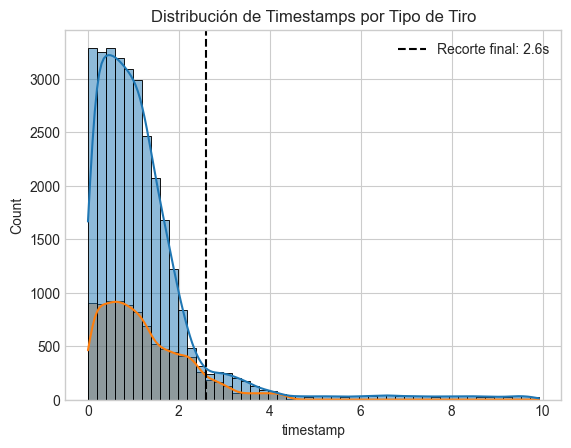

In [68]:
# Graficamos histogramas de count de timestamp para cada tipo de 
# .
cutoff = 2.6

plt.style.use('seaborn-v0_8-whitegrid')

ax = sns.histplot(data=df_results, x="timestamp", hue="is_exito", bins=50, kde=True)

plt.axvline(cutoff, color='black', linestyle='--', label=f'Recorte final: {cutoff}s')

plt.legend() 

plt.title("Distribución de Timestamps por Tipo de Tiro")
plt.show()

De lo que se observa, después del segundo 2.6 aproximadamente, deja de haber datos, lo que sugiere que el tiro ha terminado. Por lo tanto, se puede establecer un umbral de tiempo para eliminar los datos posteriores a ese punto.

In [69]:
# corte después del segundo 2.6
df_results = df_results[df_results["timestamp"] <= 2.6]

Ahora, veamos cuantos datos tenemos por cada tipo de tiro (exitoso o fallido) y por cada sensor.

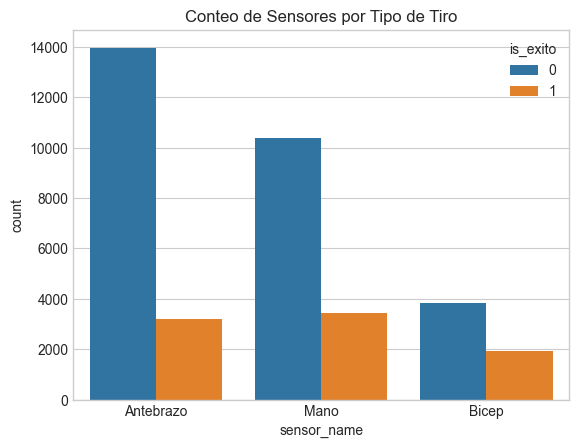

In [70]:
# Graficamos counts de sensor_name para cada tipo de tiro.
sns.countplot(data=df_results, x="sensor_name", hue="is_exito")
plt.title("Conteo de Sensores por Tipo de Tiro")
plt.show()

Se tienen más datos de los sensores del antebrazo, y de la mano; del bicep no hay tantos datos. Esto se debe a fallos en la recolección de datos.

Graficamos ahora una muestra de los datos de un sensor al azar (acc_z), para ver su comportamiento a lo largo del tiro.

Text(0.5, 1.0, 'AccX para Erick - Bicep')

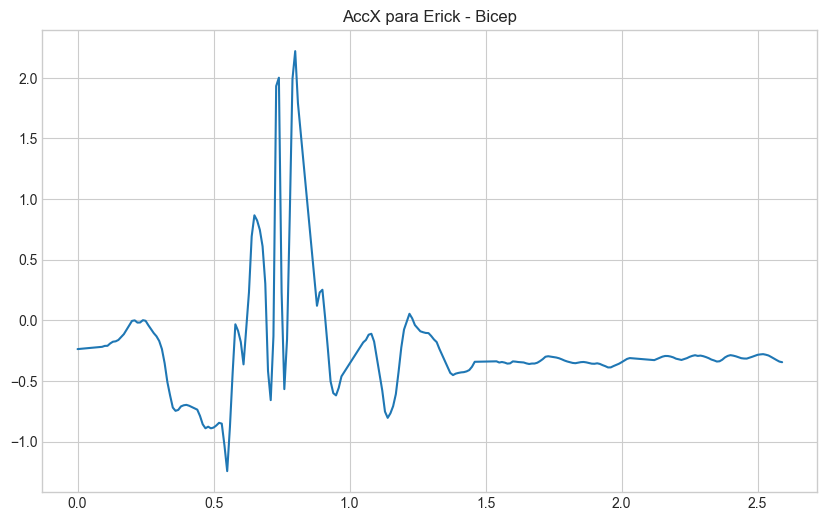

In [71]:
# Graficamos aleatoriamente 1 muestra, el acc_x, de un solo sensor.
random.seed(42)
random_student = random.choice(df_results["student_id"].unique())

sample_data = df_results[(df_results["student_id"] == random_student)]
random_sample = random.choice(sample_data["sample_number"].unique())
sample_data = sample_data[sample_data["sample_number"] == random_sample]
random_sensor = random.choice(sample_data["sensor_name"].unique())
random_sensor_data = sample_data[sample_data["sensor_name"] == random_sensor]

plt.figure(figsize=(10, 6))
plt.plot(random_sensor_data["timestamp"], random_sensor_data["acc_z"])
plt.title(f"AccX para {random_student} - {random_sensor}")

La siguiente función aplica un filtro butterworth a los datos, para suavizarlos y eliminar el ruido de alta frecuencia.

In [72]:
def apply_butterworth_filter(columna_datos, fs, fc, order=4):
    """
    Aplica un filtro pasa-bajas Butterworth
    """
    nyq = 0.5 * fs 
    normal_cutoff = fc / nyq
    
    # Diseño  del filtro
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Aplicar el filtro hacia adelante y hacia atrás
    datos_filtered = filtfilt(b, a, columna_datos)
    
    return datos_filtered

Mostramos el resultado del filtro aplicado a los datos de acc_z para un sensor específico, para visualizar la diferencia entre los datos originales y los suavizados.

C:\Users\Zarif\AppData\Local\Temp\ipykernel_39840\2321541555.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_sensor_data["acc_z_filtered"] = apply_butterworth_filter(random_sensor_data["acc_z"], fs, fc)


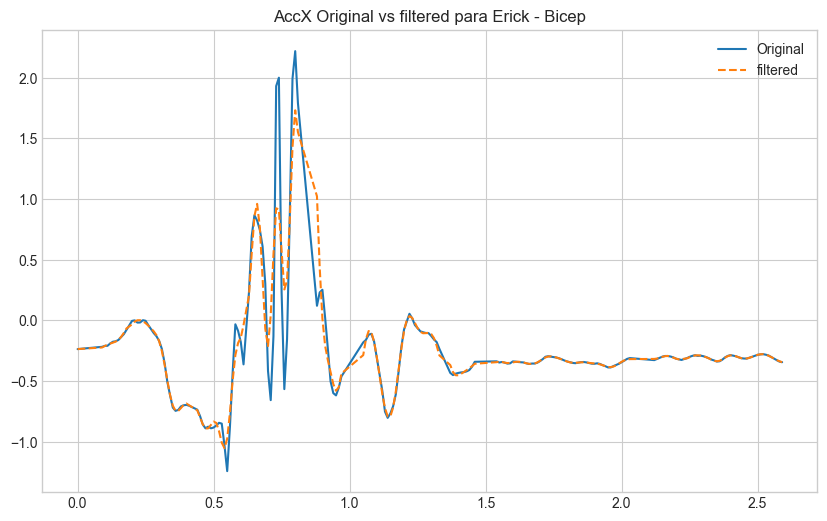

In [73]:
# Aplicamos el filtro a la columna acc_x del sensor seleccionado
fs = 100  # Frecuencia de muestreo
fc = 15    # Frecuencia de corte
random_sensor_data["acc_z_filtered"] = apply_butterworth_filter(random_sensor_data["acc_z"], fs, fc)

# Graficamos ambos, el original y el filtered.
plt.figure(figsize=(10, 6))
plt.plot(random_sensor_data["timestamp"], random_sensor_data["acc_z"], label="Original")
plt.plot(random_sensor_data["timestamp"], random_sensor_data["acc_z_filtered"], label="filtered", linestyle='--')
plt.title(f"AccX Original vs filtered para {random_student} - {random_sensor}")
plt.legend()

Ahora, aplicamos el filtro a todas las muestras de aceleración, giroscopio y eulero, para cada sensor.

In [74]:
col_to_filter = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z",]
fs = 100  # Frecuencia de muestreo
fc = 15   # Frecuencia de corte

df_filtered = df_results.copy()

for col in col_to_filter:
    new_col = f"{col}_filtered"
    
    df_filtered[new_col] = df_filtered.groupby(
        ["student_id", "sample_number", "sensor_name"]
    )[col].transform(lambda x: apply_butterworth_filter(x, fs, fc))

meta_columns = ["student_id", "sample_number", "sensor_name", "timestamp", "is_exito"]
result_columns = [f"{col}_filtered" for col in col_to_filter]

quat_columns = ["quat_w", "quat_x", "quat_y", "quat_z"]

df_filtered = df_filtered[meta_columns + result_columns + quat_columns]

In [75]:
df_filtered.head()

,student_id,sample_number,sensor_name,timestamp,is_exito,acc_x_filtered,acc_y_filtered,acc_z_filtered,gyro_x_filtered,gyro_y_filtered,gyro_z_filtered,quat_w,quat_x,quat_y,quat_z
0,Edgar,1,Antebrazo,0.00,0,0.711413,0.445360,-0.438848,-4.197560,-25.960860,37.276459,0.993571,-0.056051,-0.031644,-0.093133
1,Edgar,1,Antebrazo,0.01,0,0.649315,0.435367,-0.455128,3.263354,-32.921810,45.316991,0.993067,-0.057973,-0.034808,-0.096157
2,Edgar,1,Antebrazo,0.02,0,0.592540,0.425274,-0.476776,10.985503,-38.984534,53.885993,0.990365,-0.090770,-0.058823,-0.086476
3,Edgar,1,Antebrazo,0.03,0,0.558386,0.415191,-0.510926,19.364441,-44.162673,62.866879,0.989415,-0.094731,-0.063465,-0.089757
4,Edgar,1,Antebrazo,0.04,0,0.570244,0.406281,-0.563958,29.028587,-49.428515,71.479440,0.988280,-0.099559,-0.068996,-0.092894


In [76]:
df_filtered.to_csv("sensor_data_filtered.csv", index=False)

In [77]:
df_filtered.head()

,student_id,sample_number,sensor_name,timestamp,is_exito,acc_x_filtered,acc_y_filtered,acc_z_filtered,gyro_x_filtered,gyro_y_filtered,gyro_z_filtered,quat_w,quat_x,quat_y,quat_z
0,Edgar,1,Antebrazo,0.00,0,0.711413,0.445360,-0.438848,-4.197560,-25.960860,37.276459,0.993571,-0.056051,-0.031644,-0.093133
1,Edgar,1,Antebrazo,0.01,0,0.649315,0.435367,-0.455128,3.263354,-32.921810,45.316991,0.993067,-0.057973,-0.034808,-0.096157
2,Edgar,1,Antebrazo,0.02,0,0.592540,0.425274,-0.476776,10.985503,-38.984534,53.885993,0.990365,-0.090770,-0.058823,-0.086476
3,Edgar,1,Antebrazo,0.03,0,0.558386,0.415191,-0.510926,19.364441,-44.162673,62.866879,0.989415,-0.094731,-0.063465,-0.089757
4,Edgar,1,Antebrazo,0.04,0,0.570244,0.406281,-0.563958,29.028587,-49.428515,71.479440,0.988280,-0.099559,-0.068996,-0.092894


## Extracción de características

In [78]:
df_filtered = pd.read_csv("sensor_data_filtered.csv")

In [79]:
# Función para calcular la amplitud de una serie de datos
def amplitude(x):
    return x.max() - x.min()

La siguiente función, obtiene las características 'media', 'desviación estándar', máximo, mínimo y amplitud de nuestro dataset filtrado. Además, lo aplana para tenerlo en un formato wide donde cada fila corresponde a una muestra de tiro, y cada columna corresponde a una característica de un sensor específico.

In [80]:
def extract_features(df):
    num_cols = [
        "acc_x_filtered",
        "acc_y_filtered",
        "acc_z_filtered",
        "gyro_x_filtered",
        "gyro_y_filtered",
        "gyro_z_filtered",
        "quat_w",
        "quat_x",
        "quat_y",
        "quat_z",
    ]

    feats = ["mean", "std", "max", "min", amplitude]

    df_aux = df.groupby(
        ["student_id", "sample_number", "is_exito", "sensor_name"]
    )[num_cols].agg(feats)

    # Aplanamos las columnas generadas
    df_aux.columns = [f"{col}_{stat}" for col, stat in df_aux.columns]

    df_features = df_aux.unstack(level="sensor_name")

    df_features.columns = [f"{col}_{sensor}" for col, sensor in df_features.columns]

    df_features = df_features.fillna(0)

    df_features = df_features.reset_index()

    return df_features

In [81]:
df_features_wide = extract_features(df_filtered)

In [82]:
df_features_wide.head()

,student_id,sample_number,is_exito,acc_x_filtered_mean_Antebrazo,acc_x_filtered_mean_Bicep,acc_x_filtered_mean_Mano,acc_x_filtered_std_Antebrazo,acc_x_filtered_std_Bicep,acc_x_filtered_std_Mano,acc_x_filtered_max_Antebrazo,...,quat_z_std_Mano,quat_z_max_Antebrazo,quat_z_max_Bicep,quat_z_max_Mano,quat_z_min_Antebrazo,quat_z_min_Bicep,quat_z_min_Mano,quat_z_amplitude_Antebrazo,quat_z_amplitude_Bicep,quat_z_amplitude_Mano
0,Edgar,1,0,0.429372,0.0,0.0,1.054128,0.0,0.0,3.443710,...,0.0,0.401480,0.0,0.0,-0.225251,0.0,0.0,0.626731,0.0,0.0
1,Edgar,2,0,0.450176,0.0,0.0,0.575275,0.0,0.0,1.682391,...,0.0,0.452428,0.0,0.0,0.039548,0.0,0.0,0.412880,0.0,0.0
2,Edgar,3,0,0.139108,0.0,0.0,0.690114,0.0,0.0,1.225900,...,0.0,0.741708,0.0,0.0,-0.432404,0.0,0.0,1.174113,0.0,0.0
3,Edgar,4,0,0.403788,0.0,0.0,1.074822,0.0,0.0,3.299856,...,0.0,0.468661,0.0,0.0,-0.260524,0.0,0.0,0.729185,0.0,0.0
4,Edgar,5,0,0.286112,0.0,0.0,1.083860,0.0,0.0,1.978960,...,0.0,0.406999,0.0,0.0,-0.083732,0.0,0.0,0.490731,0.0,0.0


La siguiente función normaliza las características utilizando StandardScaler, regresa un DataFrame con las características normalizadas y el scaler utilizado, para poder aplicar la misma transformación a los datos de prueba posteriormente.

In [83]:
def normalize_features(df):
    """
    Normaliza las características numéricas del DataFrame, dejando intactas las columnas de identificación.
    Devuelve un nuevo DataFrame con las características normalizadas y las columnas de identificación originales.
    """
    df_scaled_full = df.copy()
    
    columnas_ignoradas = ['student_id', 'sample_number', 'is_exito']
    features_cols = [col for col in df.columns if col not in columnas_ignoradas]
    
    X_raw = df[features_cols]
    
    # Escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    df_scaled_full[features_cols] = X_scaled
    
    return df_scaled_full, scaler

In [84]:
df_features_wide_normalized, scaler = normalize_features(df_features_wide)

In [85]:
df_features_wide_normalized.head()

,student_id,sample_number,is_exito,acc_x_filtered_mean_Antebrazo,acc_x_filtered_mean_Bicep,acc_x_filtered_mean_Mano,acc_x_filtered_std_Antebrazo,acc_x_filtered_std_Bicep,acc_x_filtered_std_Mano,acc_x_filtered_max_Antebrazo,...,quat_z_std_Mano,quat_z_max_Antebrazo,quat_z_max_Bicep,quat_z_max_Mano,quat_z_min_Antebrazo,quat_z_min_Bicep,quat_z_min_Mano,quat_z_amplitude_Antebrazo,quat_z_amplitude_Bicep,quat_z_amplitude_Mano
0,Edgar,1,0,0.456477,-0.521833,-0.090282,0.342870,-0.542374,-1.436601,0.141019,...,-1.263411,-0.089417,0.0,-1.319451,0.267607,0.0,1.001537,-0.232557,0.0,-1.35299
1,Edgar,2,0,0.501808,-0.521833,-0.090282,-0.971974,-0.542374,-1.436601,-0.995797,...,-1.263411,0.142497,0.0,-1.319451,1.432214,0.0,1.001537,-0.850428,0.0,-1.35299
2,Edgar,3,0,-0.175985,-0.521833,-0.090282,-0.656645,-0.542374,-1.436601,-1.290432,...,-1.263411,1.459281,0.0,-1.319451,-0.643467,0.0,1.001537,1.348971,0.0,-1.35299
3,Edgar,4,0,0.400731,-0.521833,-0.090282,0.399692,-0.542374,-1.436601,0.048171,...,-1.263411,0.216389,0.0,-1.319451,0.112476,0.0,1.001537,0.063460,0.0,-1.35299
4,Edgar,5,0,0.144325,-0.521833,-0.090282,0.424508,-0.542374,-1.436601,-0.804381,...,-1.263411,-0.064296,0.0,-1.319451,0.890020,0.0,1.001537,-0.625499,0.0,-1.35299


In [86]:
df_features_wide_normalized.to_csv("sensor_features_normalized.csv", index=False)

In [87]:
def plot_pca_analysis(df_scaled):
    """
    Ejecuta el análisis de PCA y genera la gráfica de solapamiento de clases (Éxito vs No Éxito), además de mostrar la influencia de cada característica.
    """
    columnas_ignoradas = ["student_id", "sample_number", "is_exito"]
    features_cols = [col for col in df_scaled.columns if col not in columnas_ignoradas]

    X_scaled = df_scaled[features_cols]

    labels_exito = df_scaled["is_exito"].map({0: "No Éxito", 1: "Éxito"})
    labels_student = df_scaled["student_id"]

    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(X_scaled)

    # Configurar y generar la gráfica
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=pca_results[:, 0],
        y=pca_results[:, 1],
        hue=labels_exito,  # Color por éxito o fracaso
        style=labels_student,  # Forma geométrica por estudiante
        palette={
            "No Éxito": "#e74c3c",
            "Éxito": "#2ecc71",
        },
        s=150,
        alpha=0.8,
        edgecolor="black",
    )

    # Añadir métricas de varianza en los ejes
    plt.title("Análisis PCA - Diferenciación de Tiros (Éxito vs No Éxito)", fontsize=15)
    plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%})")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    loadings = pd.DataFrame(
        pca.components_.T, columns=["PC1", "PC2"], index=features_cols
    )

    print("\nInfluencia de las características en los componentes:")
    print(loadings.abs().sort_values(by="PC1", ascending=False).head(15))

    return pca

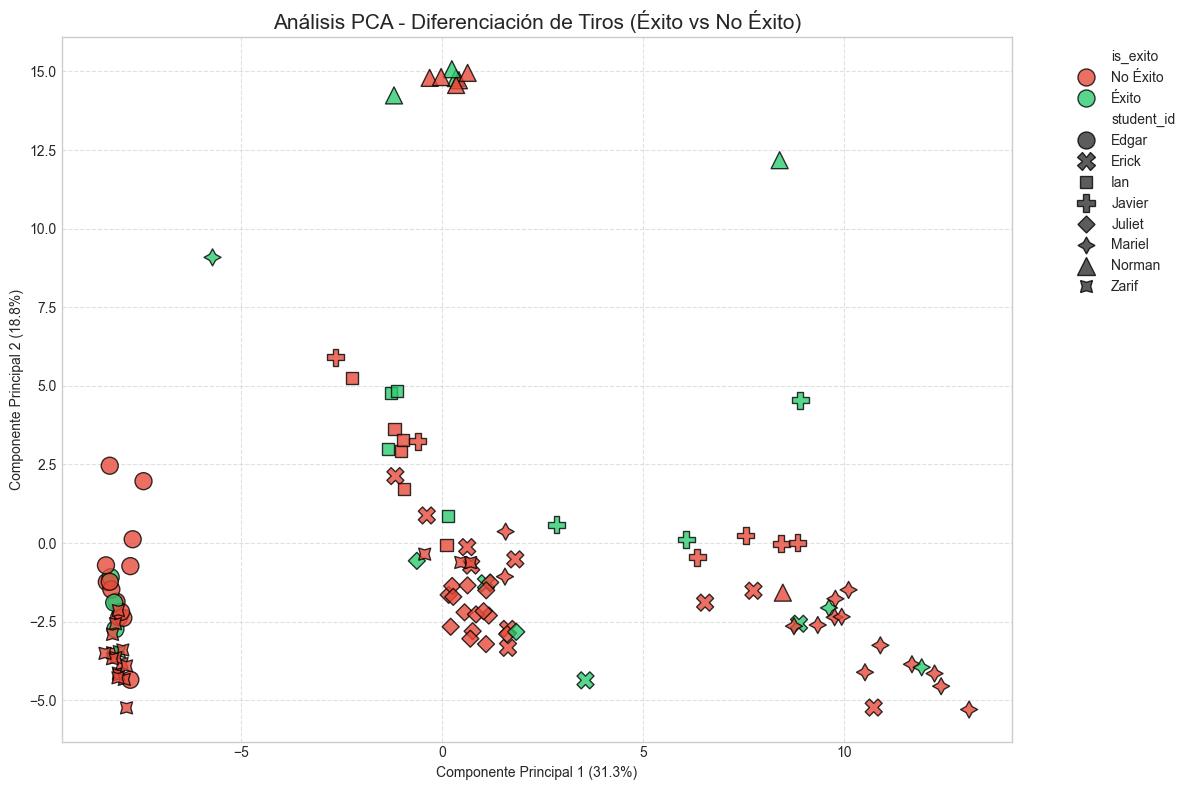


Influencia de las características en los componentes:
                                      PC1       PC2
gyro_z_filtered_std_Mano         0.134165  0.042946
gyro_z_filtered_min_Mano         0.134064  0.018658
acc_y_filtered_amplitude_Mano    0.129477  0.043458
gyro_z_filtered_amplitude_Mano   0.129416  0.025723
acc_y_filtered_std_Mano          0.129294  0.042121
quat_y_amplitude_Mano            0.129169  0.015799
quat_y_std_Mano                  0.128092  0.011575
acc_y_filtered_max_Mano          0.127581  0.038042
quat_x_amplitude_Mano            0.127248  0.032381
quat_w_amplitude_Mano            0.126430  0.065159
gyro_y_filtered_std_Bicep        0.126196  0.045919
acc_x_filtered_amplitude_Bicep   0.126167  0.039241
gyro_y_filtered_amplitude_Bicep  0.126102  0.043893
quat_w_min_Bicep                 0.126047  0.033551
quat_w_max_Bicep                 0.126047  0.033551


In [88]:
pca=plot_pca_analysis(df_features_wide_normalized)

## Evaluación Interna

Se utilizarán los modelos Random Forest, Support Vector Machine (SVM), XGBoost, Regresión Logística y MLP.

### Definición de modelos

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [90]:
modelos_a_evaluar = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42, eval_metric="logloss"
    ),
    "SVM": SVC(
        kernel="rbf", probability=True, random_state=42, class_weight="balanced"
    ),
    "Regresion Logistica": LogisticRegression(
        max_iter=10000, random_state=42, class_weight="balanced"
    ),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

### Entrenamiento

La siguiente función es utilizada para realizar el entrenamiento y evaluación de los modelos utilizando validación cruzada con K-Fold.

In [91]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_models(models, X, y, nombres_clases=["No Éxito", "Éxito"]):
    
    resultados_f1 = {}
    resultados_acc = {}
    
    sgkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for nombre, model in models.items():
        print(f"\n{'='*50}")
        print(f" EVALUANDO: {nombre} ")
        print(f"{'='*50}")
        
        # Arreglos para guardar las predicciones de todos los folds
        oof_preds = np.zeros(len(y))
        
        for i, (train_idx, val_idx) in enumerate(sgkf.split(X, y)):
            # Separar los datos
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
            
            model.fit(X_train, y_train)
            
            # Predecir el fold de validación
            preds = model.predict(X_val)
            oof_preds[val_idx] = preds
            
            # Metricas del fold
            acc_fold = accuracy_score(y_val, preds)
            print(f"Fold {i+1}: Accuracy = {acc_fold:.4f}")
            
        # --- MÉTRICAS GLOBALES DEL MODELO ---
        acc_total = accuracy_score(y, oof_preds)
        f1_total = f1_score(y, oof_preds, average="macro")
        
        resultados_acc[nombre] = acc_total
        resultados_f1[nombre] = f1_total
        
        print(f"\nResultados Finales para {nombre}:")
        print(f"Accuracy: {acc_total:.2%}")
        print(f"F1-Score Macro: {f1_total:.4f}")
        
        # Matriz de Confusión
        cm = confusion_matrix(y, oof_preds)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                    xticklabels=nombres_clases, yticklabels=nombres_clases)
        plt.title(f"Matriz de Confusión - {nombre}")
        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.show()

    # Resumen final
    print("--- RESUMEN FINAL DE MODELOS ---")
    resumen_df = pd.DataFrame({
        "Accuracy": resultados_acc,
        "F1-Score Macro": resultados_f1
    }).sort_values(by="F1-Score Macro", ascending=False)
    
    print(resumen_df)
    return resumen_df


 EVALUANDO: Random Forest 
Fold 1: Accuracy = 0.7826
Fold 2: Accuracy = 0.7727
Fold 3: Accuracy = 0.8182
Fold 4: Accuracy = 0.8182
Fold 5: Accuracy = 0.8636

Resultados Finales para Random Forest:
Accuracy: 81.08%
F1-Score Macro: 0.5835


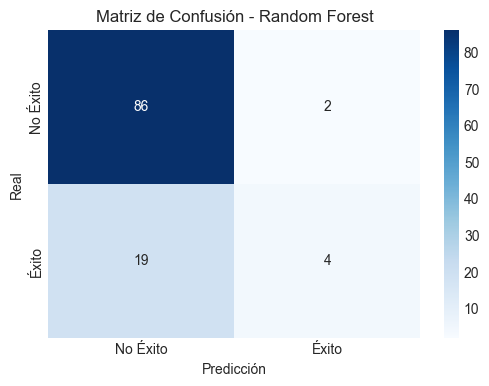


 EVALUANDO: XGBoost 
Fold 1: Accuracy = 0.7826
Fold 2: Accuracy = 0.7727
Fold 3: Accuracy = 0.7273
Fold 4: Accuracy = 0.7273
Fold 5: Accuracy = 0.6818

Resultados Finales para XGBoost:
Accuracy: 73.87%
F1-Score Macro: 0.4563


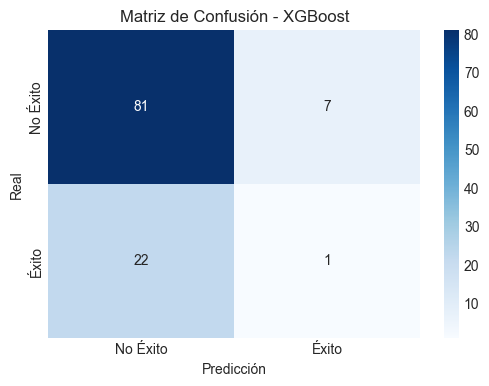


 EVALUANDO: SVM 
Fold 1: Accuracy = 0.7391
Fold 2: Accuracy = 0.5909
Fold 3: Accuracy = 0.5000
Fold 4: Accuracy = 0.5455
Fold 5: Accuracy = 0.5455

Resultados Finales para SVM:
Accuracy: 58.56%
F1-Score Macro: 0.4951


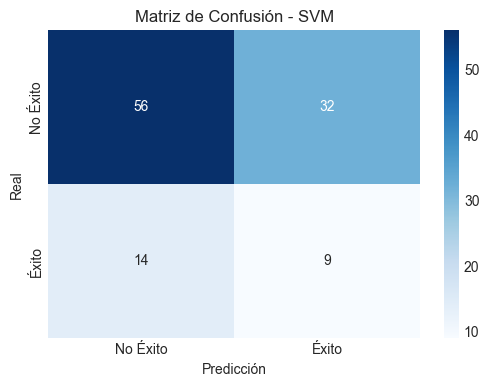


 EVALUANDO: Regresion Logistica 
Fold 1: Accuracy = 0.6957
Fold 2: Accuracy = 0.6818
Fold 3: Accuracy = 0.7273
Fold 4: Accuracy = 0.5909
Fold 5: Accuracy = 0.4545

Resultados Finales para Regresion Logistica:
Accuracy: 63.06%
F1-Score Macro: 0.5045


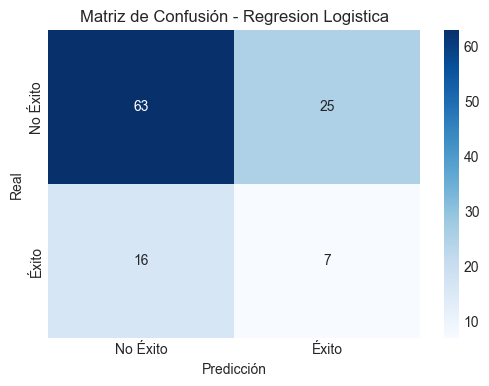


 EVALUANDO: MLP 
Fold 1: Accuracy = 0.8261
Fold 2: Accuracy = 0.6364
Fold 3: Accuracy = 0.6818
Fold 4: Accuracy = 0.7273
Fold 5: Accuracy = 0.8182

Resultados Finales para MLP:
Accuracy: 73.87%
F1-Score Macro: 0.5490


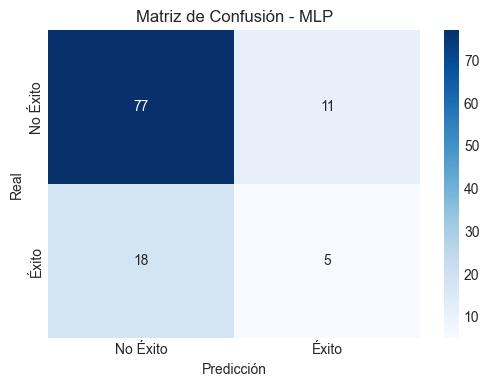

--- RESUMEN FINAL DE MODELOS ---
                     Accuracy  F1-Score Macro
Random Forest        0.810811        0.583527
MLP                  0.738739        0.548970
Regresion Logistica  0.630631        0.504518
SVM                  0.585586        0.495055
XGBoost              0.738739        0.456342


In [92]:
columnas_id = ['student_id', 'sample_number', 'is_exito']
features_cols = [col for col in df_features_wide_normalized.columns if col not in columnas_id]

X_input = df_features_wide_normalized[features_cols]
y_target = df_features_wide_normalized['is_exito']

model_results = evaluate_models(
    models=modelos_a_evaluar, 
    X=X_input, 
    y=y_target, 
)

## Validación Externa

### Selección del mejor modelo y entrenamiento final

**Discusión:** 
- El mejor modelo fue el **Random Forest**, con un accuracy de 0.810811 y un F1-Score Macro de 0.583527. Sin embargo, el mayor problema es que es 'malo' clasificando los tiros exitosos (en realidad, todos lo son). Esto se debe a que el dataset está desbalanceado, con más muestras de tiros fallidos que exitosos, a la vez que los datos no fueron correctamente recolectados.
- Nota: se probaron varias combinaciones de hiperparámetros para cada modelo, pero no se logró mejorar significativamente el rendimiento, lo que sugiere que el problema principal radica en la calidad y cantidad de los datos, más que en la elección del modelo o sus parámetros. De igual forma se hizo lo mismo con la selección de características, pero no se logró mejorar el rendimiento.

=> Se entrenará el modelo de Regresión Logística con todo el dataset, para luego realizar la predicción en el dataset de externo.

In [93]:
selected_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")


selected_model.fit(X_input, y_target)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizamos el procesamiento en el conjunto de prueba, de la misma forma que con datos del conjunto de entrenamiento.

In [94]:
dataset_externo_path = './test'

In [95]:
random.seed(42)

In [96]:
dataset_externo_df = pd.DataFrame(
    columns=[
        "file_name",
        "file_path",
        "student_id",
        "sample_number",
    ]
)

rows = []
for root, dirs, files in os.walk(dataset_externo_path):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-z]+)_([0-9]+)\.csv", file)
            if match:
                student_id = match.group(1)
                sample_number = match.group(2)
                
                rows.append(
                    {
                        "file_name": file,
                        "file_path": file_path,
                        "student_id": student_id,
                        "sample_number": sample_number,
                    }
                )

dataset_externo_df = pd.concat([dataset_externo_df, pd.DataFrame(rows)], ignore_index=True)

sensor_id_mapping = {
    5: "Antebrazo",
    4: "Bicep",
    2: "Mano",
}

In [97]:
all_results = []
for idx, row in tqdm(dataset_externo_df.iterrows(), total=dataset_externo_df.shape[0]):
    file_path = row["file_path"]
    student_id = row["student_id"]
    sample_number = int(row["sample_number"])

    data_sensor = pd.read_csv(file_path)

    data_sensor["sensor_name"] = data_sensor["SensorId"].map(sensor_id_mapping)
    
    for _, sensor_row in data_sensor.iterrows():
        all_results.append(
            {
                "student_id": student_id,
                "sample_number": sample_number,
                "sensor_name": sensor_row["sensor_name"],
                **sensor_row
            }
        )

100%|██████████| 30/30 [00:01<00:00, 24.19it/s]


In [98]:
df_results = pd.DataFrame(all_results)
df_results.head()

,student_id,sample_number,sensor_name,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,Joan,1,Antebrazo,5,-0.0002,0,0.658719,0.417145,0.549117,-10.619101,...,-0.104047,-0.058064,-0.424691,-0.110716,-0.025696,-0.050058,0.0,0.0,0.0,0.0
1,Joan,1,Antebrazo,5,0.0098,1,0.663443,0.417382,0.536653,-14.697118,...,-0.096177,-0.069626,-0.425740,-0.114033,-0.018985,-0.056835,0.0,0.0,0.0,0.0
2,Joan,1,Antebrazo,5,0.0198,2,0.669855,0.384836,0.530703,-18.497833,...,-0.094204,-0.070193,-0.426535,-0.107662,-0.043459,-0.066359,0.0,0.0,0.0,0.0
3,Joan,1,Antebrazo,5,0.0298,3,0.659981,0.325981,0.537041,-22.360611,...,-0.091741,-0.070928,-0.427447,-0.105013,-0.097643,-0.08381,0.0,0.0,0.0,0.0
4,Joan,1,Antebrazo,5,0.0398,4,0.619357,0.260134,0.567095,-27.286682,...,-0.088925,-0.071366,-0.428483,-0.065658,-0.165515,-0.1041,0.0,0.0,0.0,0.0


In [99]:
drop_columns = [
    " Temperature (degC)",
    " HeaveMotion (m)",
    " Altitude (m)",
    " Pressure (kPa)",
    " FrameNumber",
    "SensorId",
    " MagX (uT)",
    " MagY (uT)",
    " MagZ (uT)",
    " LinAccX (g)",
    " LinAccY (g)",
    " LinAccZ (g)",
    " EulerX (deg)",
    " EulerY (deg)",
    " EulerZ (deg)",
]

df_results = df_results.drop(columns=drop_columns)

rename_columns = {
    " TimeStamp (s)": "timestamp",
    " AccX (g)": "acc_x",
    " AccY (g)": "acc_y",
    " AccZ (g)": "acc_z",
    " GyroX (deg/s)": "gyro_x",
    " GyroY (deg/s)": "gyro_y",
    " GyroZ (deg/s)": "gyro_z",
    " QuatW": "quat_w",
    " QuatX": "quat_x",
    " QuatY": "quat_y",
    " QuatZ": "quat_z",
}

df_results = df_results.rename(columns=rename_columns)
df_results = df_results.dropna(subset=["sensor_name"])

In [100]:
df_results = df_results[df_results["timestamp"] <= 2.6]

In [101]:
df_results.head()
df_results.dtypes

student_id        object
sample_number      int64
sensor_name       object
timestamp        float64
acc_x            float64
acc_y            float64
acc_z            float64
gyro_x           float64
gyro_y           float64
gyro_z           float64
quat_w           float64
quat_x           float64
quat_y           float64
quat_z           float64
dtype: object

In [102]:
col_to_filter = [
    "acc_x",
    "acc_y",
    "acc_z",
    "gyro_x",
    "gyro_y",
    "gyro_z",
]
fs = 100  # Frecuencia de muestreo
fc = 15  # Frecuencia de corte

df_filtered = df_results.copy()

for col in col_to_filter:
    new_col = f"{col}_filtered"

    df_filtered[new_col] = df_filtered.groupby(
        ["student_id", "sample_number", "sensor_name"]
    )[col].transform(lambda x: apply_butterworth_filter(x, fs, fc))

meta_columns = [
    "student_id",
    "sample_number",
    "sensor_name",
    "timestamp",
]
result_columns = [f"{col}_filtered" for col in col_to_filter]

quat_columns = ["quat_w", "quat_x", "quat_y", "quat_z"]
df_filtered = df_filtered[meta_columns + result_columns + quat_columns]

In [103]:
num_cols = [
    "acc_x_filtered",
    "acc_y_filtered",
    "acc_z_filtered",
    "gyro_x_filtered",
    "gyro_y_filtered",
    "gyro_z_filtered",
    "quat_w",
    "quat_x",
    "quat_y",
    "quat_z",
]

feats = ["mean", "std", "max", "min", amplitude]

df_aux = df_filtered.groupby(["student_id", "sample_number", "sensor_name"])[
    num_cols
].agg(feats)

# Aplanamos las columnas generadas
df_aux.columns = [f"{col}_{stat}" for col, stat in df_aux.columns]

df_features = df_aux.unstack(level="sensor_name")

df_features.columns = [f"{col}_{sensor}" for col, sensor in df_features.columns]

df_features = df_features.fillna(0)

df_features = df_features.reset_index()

In [104]:
df_scaled_full = df_features.copy()

columnas_ignoradas = ["student_id", "sample_number"]
features_cols_test = [c for c in df_scaled_full.columns if c not in columnas_ignoradas]

X_raw_test = df_scaled_full[features_cols_test]

X_raw_test = X_raw_test.reindex(columns=features_cols, fill_value=0)

X_test_scaled = scaler.transform(X_raw_test)

Ahora, aplicamos el modelo seleccionado para realizar las predicciones en el conjunto de prueba.

In [105]:
# Predecimos con el modelo seleccionado
y_pred_test = selected_model.predict(X_test_scaled)

c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [106]:
predictions_df = pd.DataFrame({
    "nombre": dataset_externo_df["file_name"],
    "pred": y_pred_test
})

In [107]:
predictions_df

,nombre,pred
0,Joan_01.csv,0
1,Joan_02.csv,0
2,Joan_03.csv,0
3,Joan_04.csv,0
4,Joan_05.csv,0
5,Joan_06.csv,0
6,Joan_07.csv,0
7,Joan_08.csv,0
8,Joan_09.csv,0
9,Joan_10.csv,0


In [108]:
predictions_df.to_csv("predicciones.csv", index=False)

### Discusión de Resultados

-  En primera instancia, y como se menciona anteriormente, los datos no fueron correctamente recolectados, lo que se refleja en la cantidad de datos faltantes por sensor, así como en la cantidad de muestras por clase.

- Se realizon pruebas rápidas utilizando data augmentation (como smote, añadir ruido, multiplicar por constante, triangular, etc.), pero no se logró mejorar el rendimiento de los modelos significativamente. Esto es compatible con la gráfica del PCA, donde se observa que las muestras de tiros exitosos y fallidos no están claramente separadas entre sí.

- Otro factor a considerar, es que los sujetos que realizaron los tiros, no eran jugadores profesionales, por lo que la variabilidad en la ejecución de los tiros es alta, lo que dificulta la tarea de clasificación.

- De igual forma, los sujetos que realizaron los tiros en el conjunto de prueba, no fueron los mismos que realizaron los tiros en el conjunto de entrenamiento, lo que añade un nivel adicional de dificultad a la tarea de clasificación, ya que el modelo no ha visto datos de esos sujetos durante su entrenamiento.